In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\babus\Data_Spark\Data_analysis_practice\Data Collection\large_multicolumn_outlier_dataset.csv")

In [3]:
df

,Customer_ID,Age,Annual_Income,Monthly_Spend,Savings,Credit_Score,Loan_Amount,Transactions_Per_Month,Avg_Transaction_Value,Account_Tenure_Years,Online_Sessions_Per_Month,Returned_Transactions
0,1,45,75548,1100,6687,807,2603,21,70,2,19,0
1,2,38,53376,2073,5071,672,19182,30,108,16,21,1
2,3,47,38753,1739,18463,629,40953,30,66,9,21,1
3,4,58,75879,1658,13109,654,21312,31,77,8,21,3
4,5,37,53302,2183,13239,780,45783,33,39,13,22,2
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,49,48515,1706,15885,588,22499,19,8,5,14,2
149996,149997,42,44688,966,8726,661,39990,31,70,8,21,0
149997,149998,37,44805,1449,13804,655,21050,27,17,3,20,1
149998,149999,41,38918,1400,14290,600,35213,45,59,5,19,3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                     Non-Null Count   Dtype
---  ------                     --------------   -----
 0   Customer_ID                150000 non-null  int64
 1   Age                        150000 non-null  int64
 2   Annual_Income              150000 non-null  int64
 3   Monthly_Spend              150000 non-null  int64
 4   Savings                    150000 non-null  int64
 5   Credit_Score               150000 non-null  int64
 6   Loan_Amount                150000 non-null  int64
 7   Transactions_Per_Month     150000 non-null  int64
 8   Avg_Transaction_Value      150000 non-null  int64
 9   Account_Tenure_Years       150000 non-null  int64
 10  Online_Sessions_Per_Month  150000 non-null  int64
 11  Returned_Transactions      150000 non-null  int64
dtypes: int64(12)
memory usage: 13.7 MB


In [5]:
df.describe()

,Customer_ID,Age,Annual_Income,Monthly_Spend,Savings,Credit_Score,Loan_Amount,Transactions_Per_Month,Avg_Transaction_Value,Account_Tenure_Years,Online_Sessions_Per_Month,Returned_Transactions
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,75000.500000,39.699007,55759.380700,1822.156993,15270.963147,678.804780,20901.353593,29.968593,59.506773,6.585427,20.006367,1.500353
std,43301.414527,11.625207,21835.526567,714.722444,9311.571621,71.640845,15577.477584,5.461724,24.701497,3.832637,4.479587,1.225815
min,1.000000,18.000000,20000.000000,300.000000,0.000000,300.000000,0.000000,8.000000,5.000000,0.000000,3.000000,0.000000
25%,37500.750000,31.000000,44909.750000,1460.000000,9575.000000,632.000000,9877.750000,26.000000,43.000000,4.000000,17.000000,1.000000
50%,75000.500000,40.000000,55010.000000,1801.000000,14999.000000,680.000000,20005.000000,30.000000,59.000000,6.000000,20.000000,1.000000
75%,112500.250000,48.000000,65170.000000,2139.000000,20423.000000,727.000000,30197.250000,34.000000,76.000000,9.000000,23.000000,2.000000
max,150000.000000,90.000000,725728.000000,24795.000000,324976.000000,900.000000,477544.000000,56.000000,167.000000,24.000000,41.000000,10.000000


In [6]:
df.nunique()

Customer_ID                  150000
Age                              71
Annual_Income                 54863
Monthly_Spend                  3482
Savings                       32290
Credit_Score                    592
Loan_Amount                   46989
Transactions_Per_Month           47
Avg_Transaction_Value           158
Account_Tenure_Years             25
Online_Sessions_Per_Month        39
Returned_Transactions            11
dtype: int64

In [7]:
df.size

1800000

In [8]:
df.columns

Index(['Customer_ID', 'Age', 'Annual_Income', 'Monthly_Spend', 'Savings',
       'Credit_Score', 'Loan_Amount', 'Transactions_Per_Month',
       'Avg_Transaction_Value', 'Account_Tenure_Years',
       'Online_Sessions_Per_Month', 'Returned_Transactions'],
      dtype='object')

In [9]:
status = df.agg(['mean','median','var','std','skew','kurtosis'])
status

,Customer_ID,Age,Annual_Income,Monthly_Spend,Savings,Credit_Score,Loan_Amount,Transactions_Per_Month,Avg_Transaction_Value,Account_Tenure_Years,Online_Sessions_Per_Month,Returned_Transactions
mean,7.500050e+04,39.699007,5.575938e+04,1822.156993,1.527096e+04,678.804780,2.090135e+04,29.968593,59.506773,6.585427,20.006367,1.500353
median,7.500050e+04,40.000000,5.501000e+04,1801.000000,1.499900e+04,680.000000,2.000500e+04,30.000000,59.000000,6.000000,20.000000,1.000000
var,1.875012e+09,135.145444,4.767902e+08,510828.171828,8.670537e+07,5132.410739,2.426578e+08,29.830432,610.163955,14.689107,20.066700,1.502623
std,4.330141e+04,11.625207,2.183553e+04,714.722444,9.311572e+03,71.640845,1.557748e+04,5.461724,24.701497,3.832637,4.479587,1.225815
skew,0.000000e+00,0.179114,1.011950e+01,9.237774,5.032449e+00,-0.202838,3.454717e+00,0.181698,0.088730,0.242500,0.226211,0.821377
kurtosis,-1.200000e+00,-0.319285,2.096729e+02,186.255007,9.469388e+01,0.719721,5.600025e+01,0.019480,-0.202551,-0.333240,0.034532,0.699258


In [10]:
status_1 = (
    df.select_dtypes(include='number')
    .agg(['mean','median','var','std','skew','kurtosis'])
)
status_1

,Customer_ID,Age,Annual_Income,Monthly_Spend,Savings,Credit_Score,Loan_Amount,Transactions_Per_Month,Avg_Transaction_Value,Account_Tenure_Years,Online_Sessions_Per_Month,Returned_Transactions
mean,7.500050e+04,39.699007,5.575938e+04,1822.156993,1.527096e+04,678.804780,2.090135e+04,29.968593,59.506773,6.585427,20.006367,1.500353
median,7.500050e+04,40.000000,5.501000e+04,1801.000000,1.499900e+04,680.000000,2.000500e+04,30.000000,59.000000,6.000000,20.000000,1.000000
var,1.875012e+09,135.145444,4.767902e+08,510828.171828,8.670537e+07,5132.410739,2.426578e+08,29.830432,610.163955,14.689107,20.066700,1.502623
std,4.330141e+04,11.625207,2.183553e+04,714.722444,9.311572e+03,71.640845,1.557748e+04,5.461724,24.701497,3.832637,4.479587,1.225815
skew,0.000000e+00,0.179114,1.011950e+01,9.237774,5.032449e+00,-0.202838,3.454717e+00,0.181698,0.088730,0.242500,0.226211,0.821377
kurtosis,-1.200000e+00,-0.319285,2.096729e+02,186.255007,9.469388e+01,0.719721,5.600025e+01,0.019480,-0.202551,-0.333240,0.034532,0.699258


In [11]:
status_2 = (
    df.select_dtypes(include='number')
    .agg(['mean','median','var','std','skew','kurtosis'])
    .T
)
status_2

,mean,median,var,std,skew,kurtosis
Customer_ID,75000.500000,75000.5,1.875012e+09,43301.414527,0.000000,-1.200000
Age,39.699007,40.0,1.351454e+02,11.625207,0.179114,-0.319285
Annual_Income,55759.380700,55010.0,4.767902e+08,21835.526567,10.119501,209.672852
Monthly_Spend,1822.156993,1801.0,5.108282e+05,714.722444,9.237774,186.255007
Savings,15270.963147,14999.0,8.670537e+07,9311.571621,5.032449,94.693884
Credit_Score,678.804780,680.0,5.132411e+03,71.640845,-0.202838,0.719721
Loan_Amount,20901.353593,20005.0,2.426578e+08,15577.477584,3.454717,56.000253
Transactions_Per_Month,29.968593,30.0,2.983043e+01,5.461724,0.181698,0.019480
Avg_Transaction_Value,59.506773,59.0,6.101640e+02,24.701497,0.088730,-0.202551
Account_Tenure_Years,6.585427,6.0,1.468911e+01,3.832637,0.242500,-0.333240


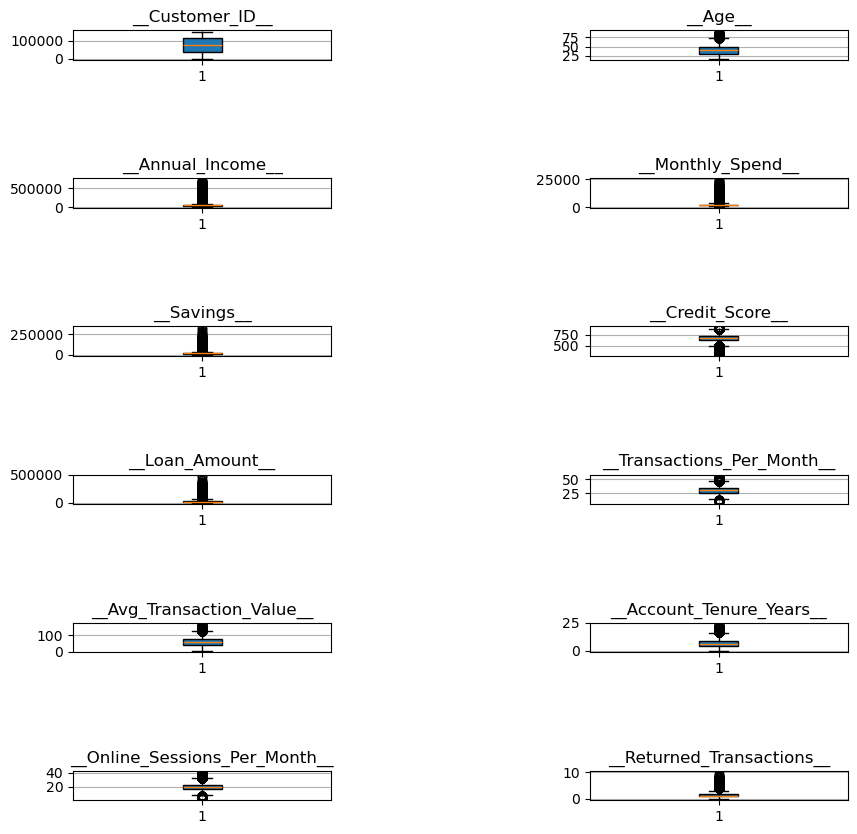

In [12]:
# plt.figure(figsize=(10,5))
# for i,col in enumerate (df.columns,start=1):
#     plt.subplot(6,2,i)
#     sns.boxplot(data=df[col],color='r')
#     plt.title(f"__{col}__")
#     plt.grid()

# plt.subplots_adjust(wspace=1,hspace=4)
# plt.show()

plt.figure(figsize=(10,10))
for i,col in enumerate (df.columns,start=1):
    plt.subplot(6,2,i)
    plt.boxplot(df[col],patch_artist=True)
    plt.title(f"__{col}__")
    plt.grid()

plt.subplots_adjust(wspace=1,hspace=4)
plt.show()

In [13]:
# Age

Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1 

lm = Q1 - IQR * 1.5
um = Q3 + IQR * 1.5

outliers = (df['Age'] > um ) | (df['Age'] < lm )
trimmed_age = df['Age'].loc[~outliers]

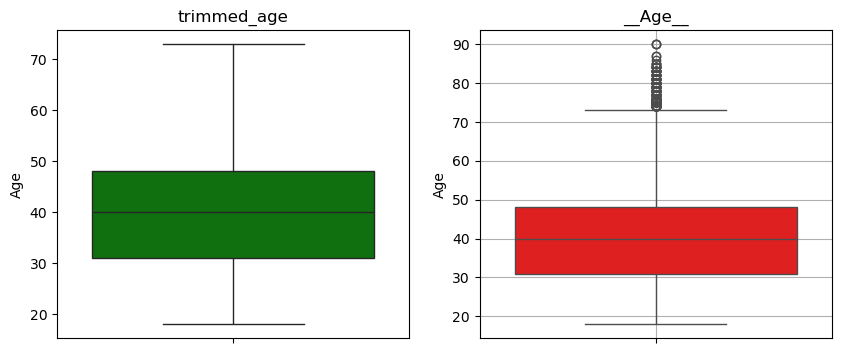

In [14]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("trimmed_age")
sns.boxplot(data = trimmed_age,color='g')
plt.subplot(1,2,2)
plt.title("__Age__")
sns.boxplot(data = df['Age'],color='r')
plt.grid()
plt.show()

In [15]:
# Annual_Income

Q1 = df['Annual_Income'].quantile(0.25)
Q3 = df['Annual_Income'].quantile(0.75)

IQR = Q3 - Q1 

lm = Q1 - IQR * 1.5
um = Q3 + IQR * 1.5

outliers = (df['Annual_Income'] < lm ) | (df['Annual_Income'] > um )
trimmed_Annual_Income = df['Annual_Income'].loc[~outliers]


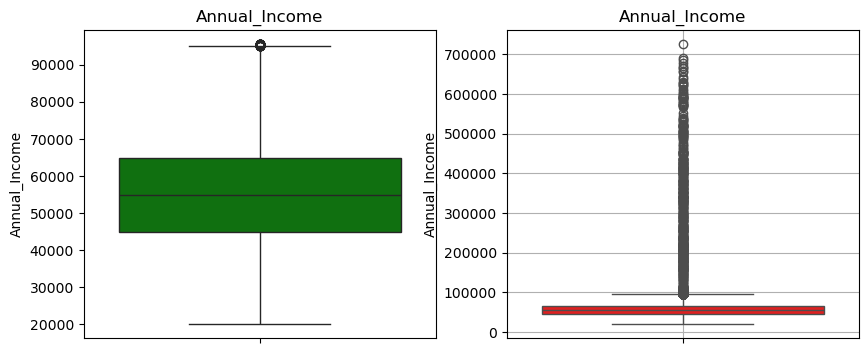

In [16]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Annual_Income")
sns.boxplot(data = trimmed_Annual_Income,color='g')
plt.subplot(1,2,2)
plt.title("Annual_Income")
sns.boxplot(data = df['Annual_Income'],color='r')
plt.grid()
plt.show()

In [17]:
# Monthly_Spend

Q1 = df['Monthly_Spend'].quantile(0.25)
Q3 = df['Monthly_Spend'].quantile(0.75)

IQR = Q3 - Q1 

lm = Q1 - IQR * 1.5
um = Q3 + IQR * 1.5

outliers = (df['Monthly_Spend'] < lm ) | (df['Monthly_Spend'] > um )
trimmed_Monthly_Spend = df['Monthly_Spend'].loc[~outliers]

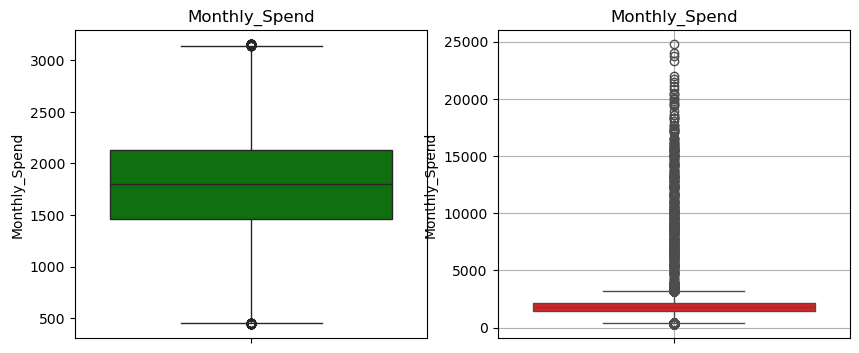

In [18]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Monthly_Spend")
sns.boxplot(data = trimmed_Monthly_Spend,color='g')
plt.subplot(1,2,2)
plt.title("Monthly_Spend")
sns.boxplot(data = df['Monthly_Spend'],color='r')
plt.grid()
plt.show()

In [19]:
# Savings

Q1 = df['Savings'].quantile(0.25)
Q3 = df['Savings'].quantile(0.75)

IQR = Q3 - Q1 

lm = Q1 - IQR * 1.5
um = Q3 + IQR * 1.5

outliers = (df['Savings'] < lm ) | (df['Savings'] > um )
trimmed_Savings = df['Savings'].loc[~outliers]

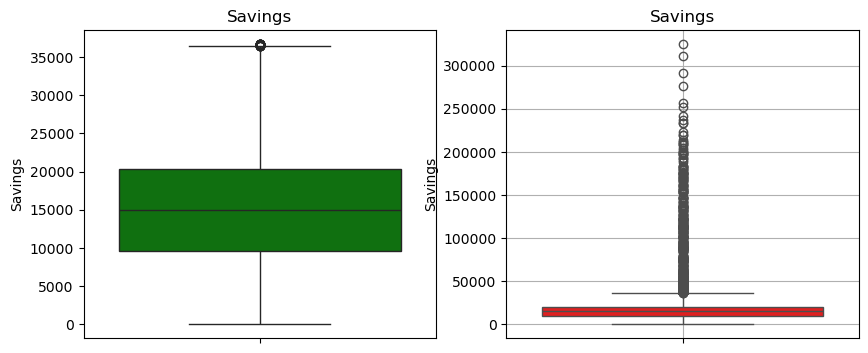

In [20]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Savings")
sns.boxplot(data = trimmed_Savings,color='g')
plt.subplot(1,2,2)
plt.title("Savings")
sns.boxplot(data = df['Savings'],color='r')
plt.grid()
plt.show()

In [21]:
# Credit_Score

Q1 = df['Credit_Score'].quantile(0.25)
Q3 = df['Credit_Score'].quantile(0.75)

IQR = Q3 - Q1 

lm = Q1 - IQR * 1.5
um = Q3 + IQR * 1.5

outliers = (df['Credit_Score'] < lm ) | (df['Credit_Score'] > um )
trimmed_Credit_Score = df['Credit_Score'].loc[~outliers]

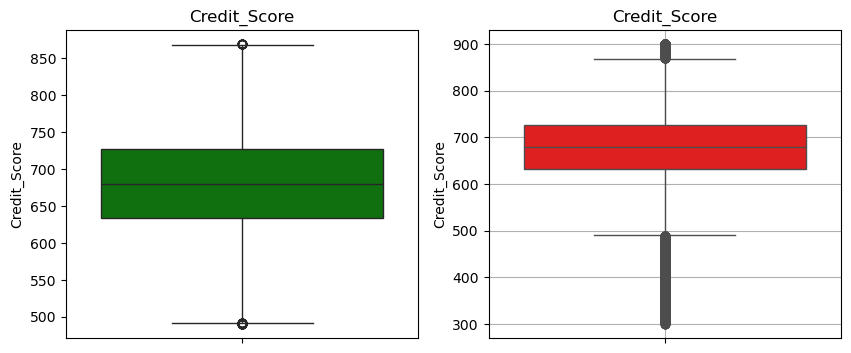

In [22]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Credit_Score")
sns.boxplot(data = trimmed_Credit_Score,color='g')
plt.subplot(1,2,2)
plt.title("Credit_Score")
sns.boxplot(data = df['Credit_Score'],color='r')
plt.grid()
plt.show()

In [23]:
# Loan_Amount

Q1 = df['Loan_Amount'].quantile(0.25)
Q3 = df['Loan_Amount'].quantile(0.75)

IQR = Q3 - Q1 

lm = Q1 - IQR * 1.5
um = Q3 + IQR * 1.5

outliers = (df['Loan_Amount'] < lm ) | (df['Loan_Amount'] > um )
trimmed_Loan_Amount = df['Loan_Amount'].loc[~outliers]

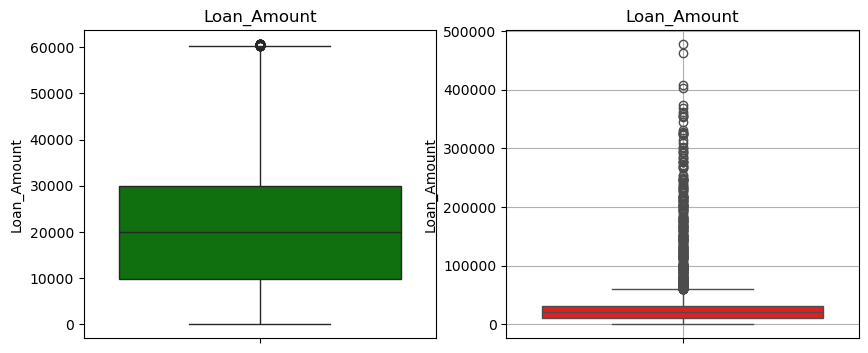

In [24]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Loan_Amount")
sns.boxplot(data = trimmed_Loan_Amount,color='g')
plt.subplot(1,2,2)
plt.title("Loan_Amount")
sns.boxplot(data = df['Loan_Amount'],color='r')
plt.grid()
plt.show()

In [25]:
# Transactions_Per_Month

Q1 = df['Transactions_Per_Month'].quantile(0.25)
Q3 = df['Transactions_Per_Month'].quantile(0.75)

IQR = Q3 - Q1 

lm = Q1 - IQR * 1.5
um = Q3 + IQR * 1.5

outliers = (df['Transactions_Per_Month'] < lm ) | (df['Transactions_Per_Month'] > um )
trimmed_Transactions_Per_Month = df['Transactions_Per_Month'].loc[~outliers]

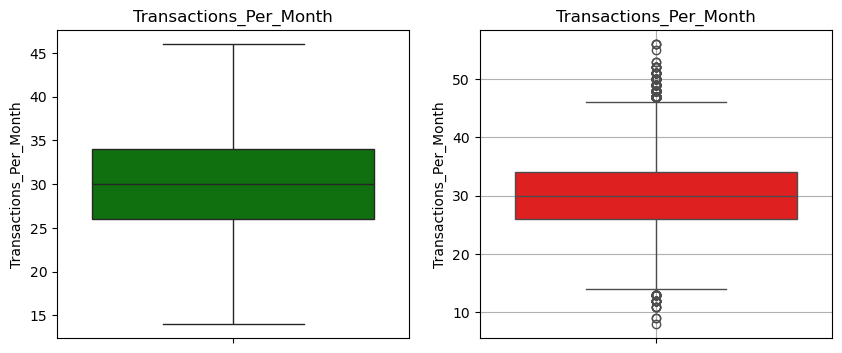

In [26]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Transactions_Per_Month")
sns.boxplot(data = trimmed_Transactions_Per_Month,color='g')
plt.subplot(1,2,2)
plt.title("Transactions_Per_Month")
sns.boxplot(data = df['Transactions_Per_Month'],color='r')
plt.grid()
plt.show()

In [27]:
# Avg_Transaction_Value

Q1 = df['Avg_Transaction_Value'].quantile(0.25)
Q3 = df['Avg_Transaction_Value'].quantile(0.75)

IQR = Q3 - Q1 

lm = Q1 - IQR * 1.5
um = Q3 + IQR * 1.5

outliers = (df['Avg_Transaction_Value'] < lm ) | (df['Avg_Transaction_Value'] > um )
trimmed_Avg_Transaction_Value = df['Avg_Transaction_Value'].loc[~outliers]

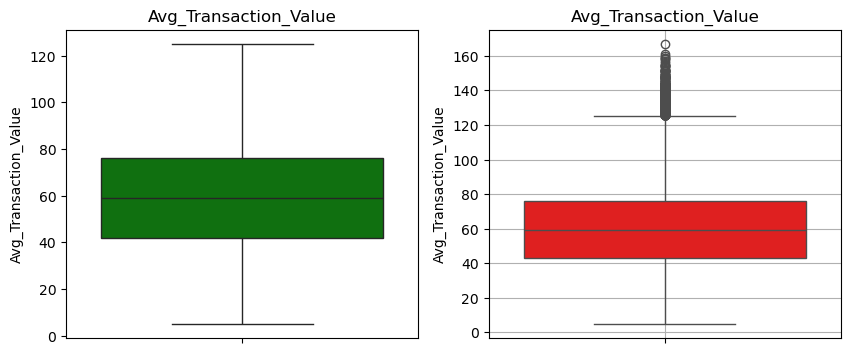

In [28]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Avg_Transaction_Value")
sns.boxplot(data = trimmed_Avg_Transaction_Value,color='g')
plt.subplot(1,2,2)
plt.title("Avg_Transaction_Value")
sns.boxplot(data = df['Avg_Transaction_Value'],color='r')
plt.grid()
plt.show()

In [29]:
# Account_Tenure_Years

Q1 = df['Account_Tenure_Years'].quantile(0.25)
Q3 = df['Account_Tenure_Years'].quantile(0.75)

IQR = Q3 - Q1 

lm = Q1 - IQR * 1.5
um = Q3 + IQR * 1.5

outliers = (df['Account_Tenure_Years'] < lm ) | (df['Account_Tenure_Years'] > um )
trimmed_Account_Tenure_Years = df['Account_Tenure_Years'].loc[~outliers]

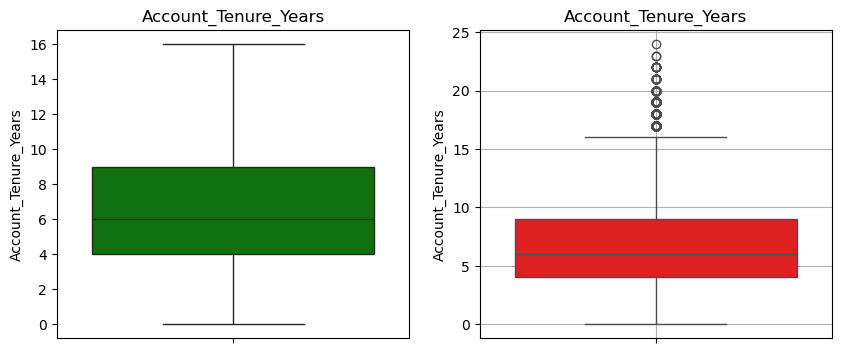

In [30]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Account_Tenure_Years")
sns.boxplot(data = trimmed_Account_Tenure_Years,color='g')
plt.subplot(1,2,2)
plt.title("Account_Tenure_Years")
sns.boxplot(data = df['Account_Tenure_Years'],color='r')
plt.grid()
plt.show()

In [31]:
# Online_Sessions_Per_Month

Q1 = df['Online_Sessions_Per_Month'].quantile(0.25)
Q3 = df['Online_Sessions_Per_Month'].quantile(0.75)

IQR = Q3 - Q1 

lm = Q1 - IQR * 1.5
um = Q3 + IQR * 1.5

outliers = (df['Online_Sessions_Per_Month'] < lm ) | (df['Online_Sessions_Per_Month'] > um )
trimmed_Online_Sessions_Per_Month = df['Online_Sessions_Per_Month'].loc[~outliers]

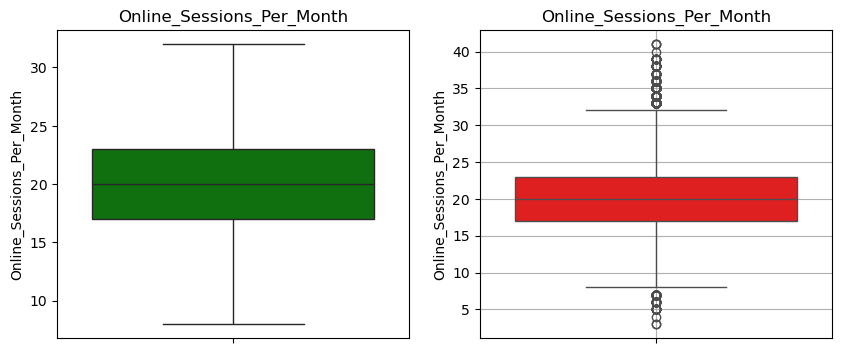

In [32]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Online_Sessions_Per_Month")
sns.boxplot(data = trimmed_Online_Sessions_Per_Month,color='g')
plt.subplot(1,2,2)
plt.title("Online_Sessions_Per_Month")
sns.boxplot(data = df['Online_Sessions_Per_Month'],color='r')
plt.grid()
plt.show()

In [33]:
# Returned_TranReturned_Transactionssactions

Q1 = df['Returned_Transactions'].quantile(0.25)
Q3 = df['Returned_Transactions'].quantile(0.75)

IQR = Q3 - Q1 

lm = Q1 - IQR * 1.5
um = Q3 + IQR * 1.5

outliers = (df['Returned_Transactions'] < lm ) | (df['Returned_Transactions'] > um )
trimmed_Returned_Transactions = df['Returned_Transactions'].loc[~outliers]

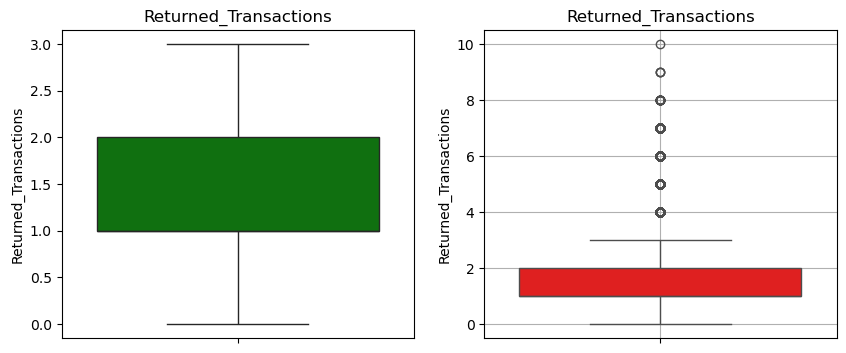

In [34]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Returned_Transactions")
sns.boxplot(data = trimmed_Returned_Transactions,color='g')
plt.subplot(1,2,2)
plt.title("Returned_Transactions")
sns.boxplot(data = df['Returned_Transactions'],color='r')

plt.grid()
plt.show()

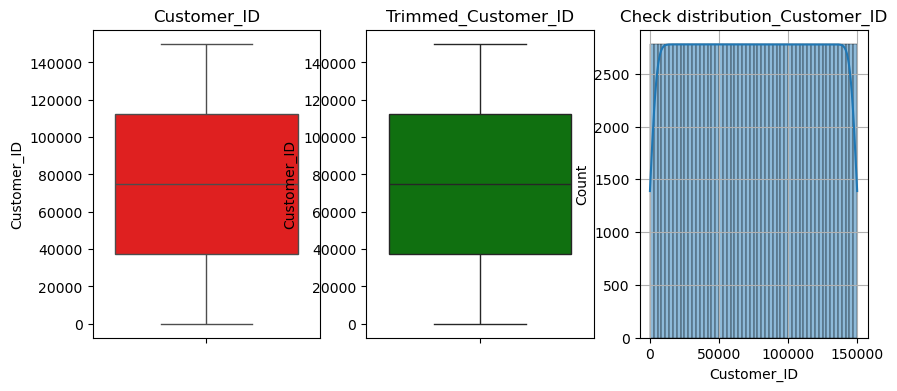

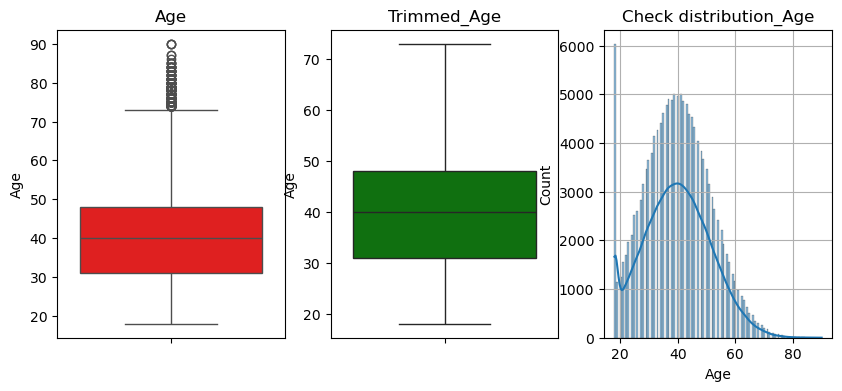

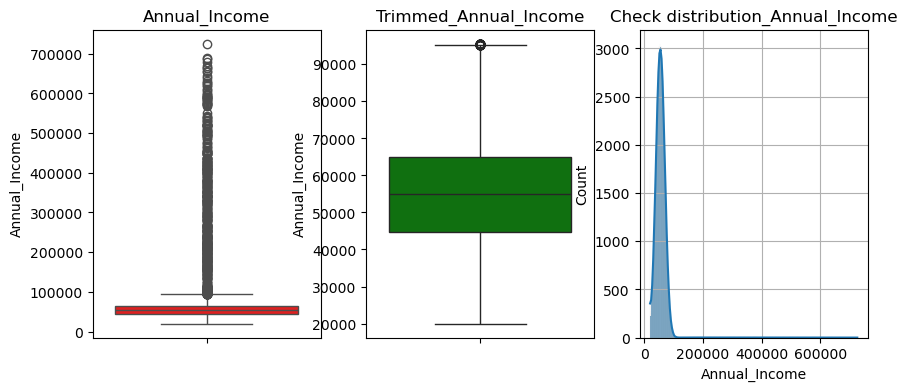

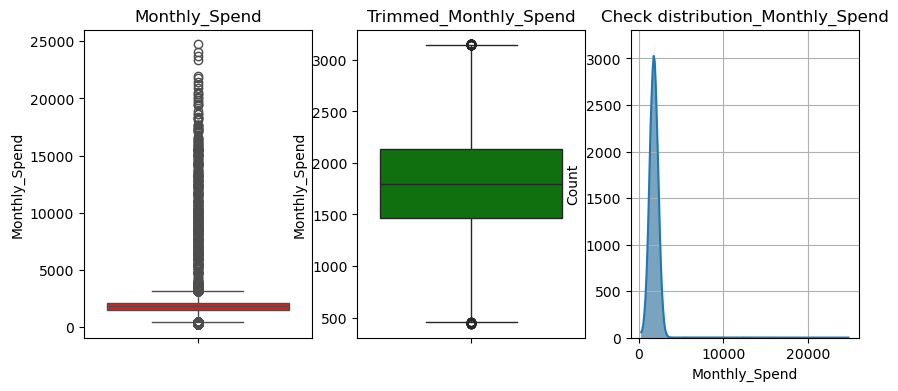

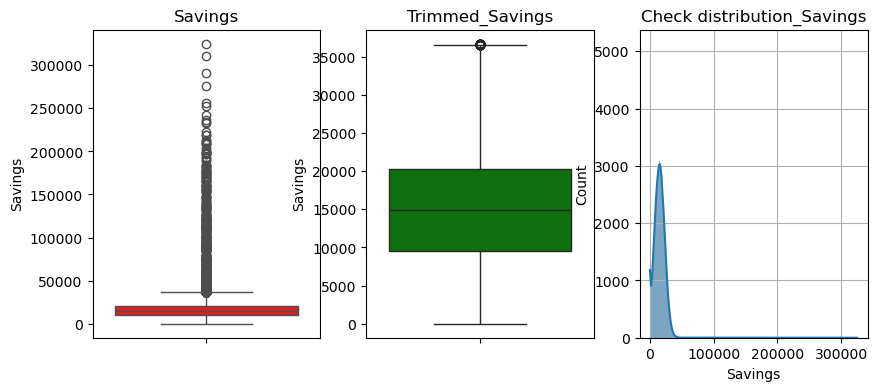

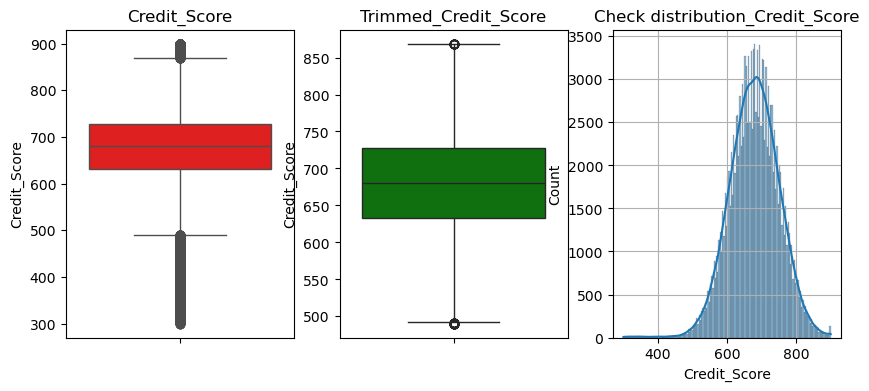

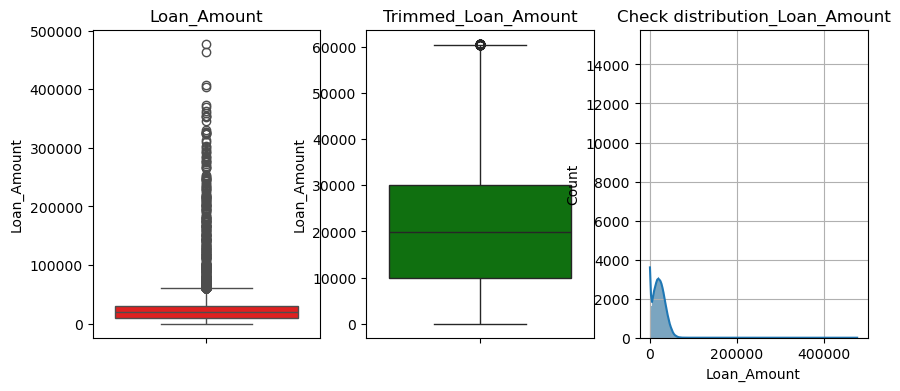

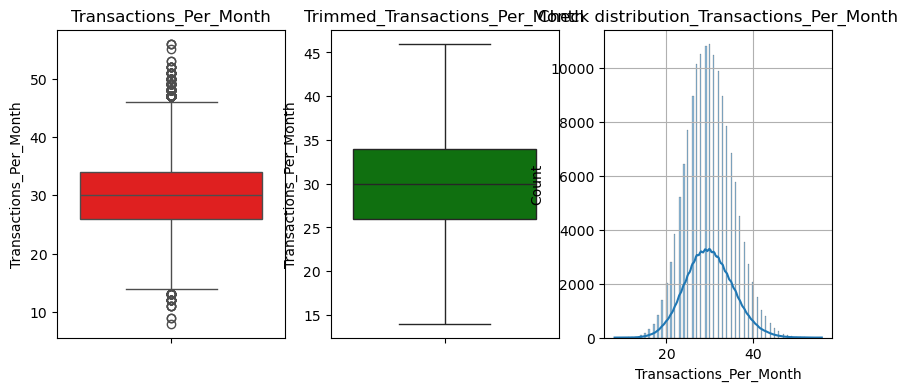

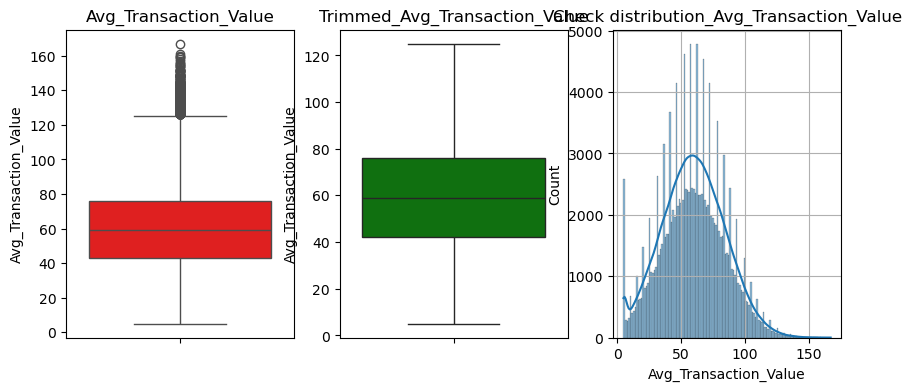

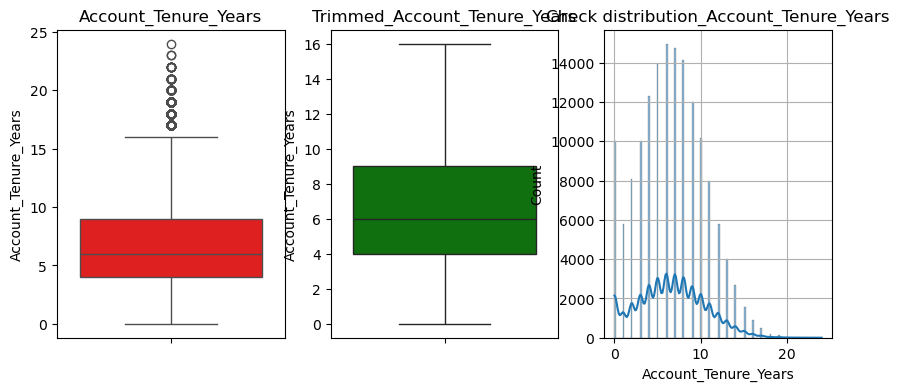

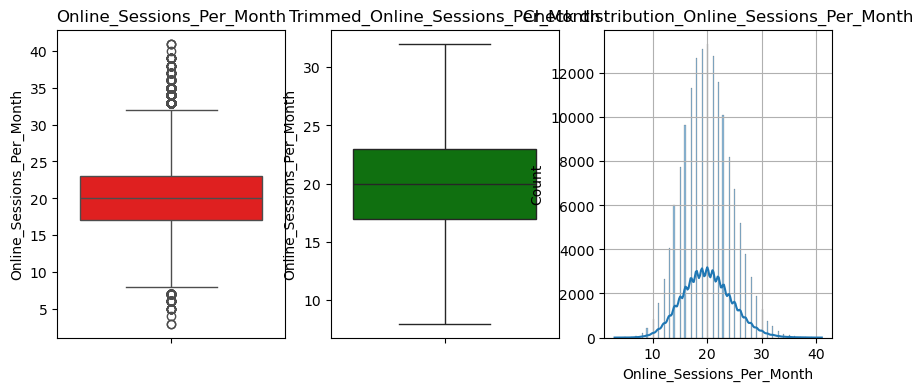

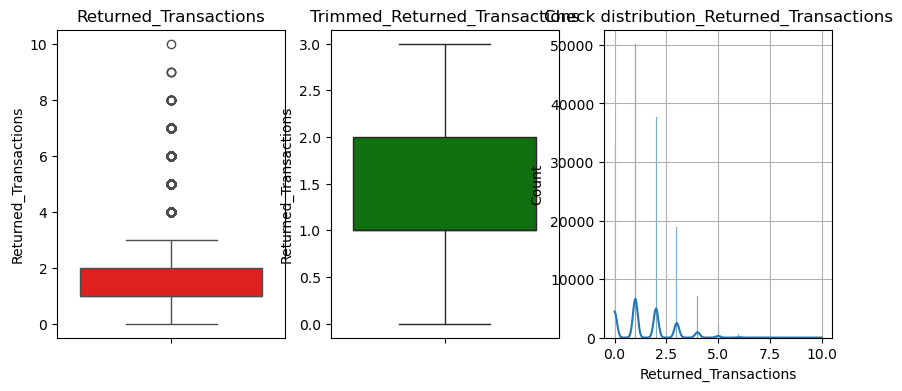

In [35]:
def clean_Data(df):
    for col in df.columns:
        
        # Cleaning
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        upper_limit = Q3 + IQR * 1.5
        lower_limit = Q1 - IQR * 1.5        
        outliers = ( df[col] > upper_limit ) | ( df[col] < lower_limit )
        trimmed  = df[col].loc[~outliers]
        
        # plotting
        plt.figure(figsize=(10,4))
        
        plt.subplot(1,3,1)
        plt.title(f"{col}")
        sns.boxplot(data = df[col],color='r')
        
        plt.subplot(1,3,2)
        plt.title(f"Trimmed_{col}")
        sns.boxplot(data = trimmed,color='g')
        
        plt.subplot(1,3,3)
        plt.title(f"Check distribution_{col}")
        sns.histplot(df[col], kde=True)
       
        plt.grid()
        plt.show()
    


clean_Data(df)

In [36]:
len(df.columns)

12

In [39]:
df.isna().sum()

Customer_ID                  0
Age                          0
Annual_Income                0
Monthly_Spend                0
Savings                      0
Credit_Score                 0
Loan_Amount                  0
Transactions_Per_Month       0
Avg_Transaction_Value        0
Account_Tenure_Years         0
Online_Sessions_Per_Month    0
Returned_Transactions        0
dtype: int64